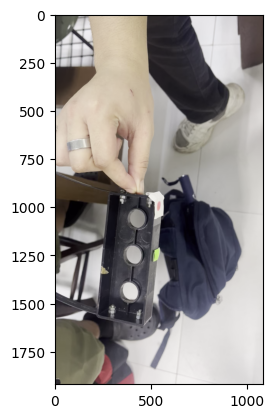

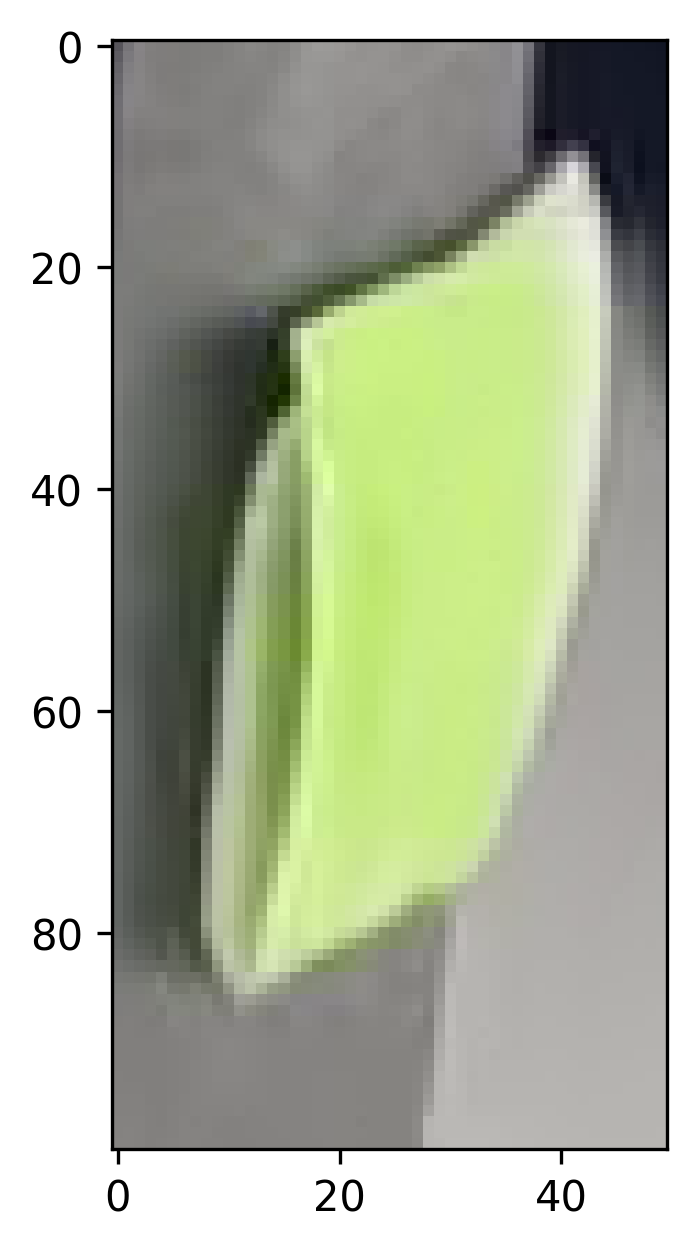

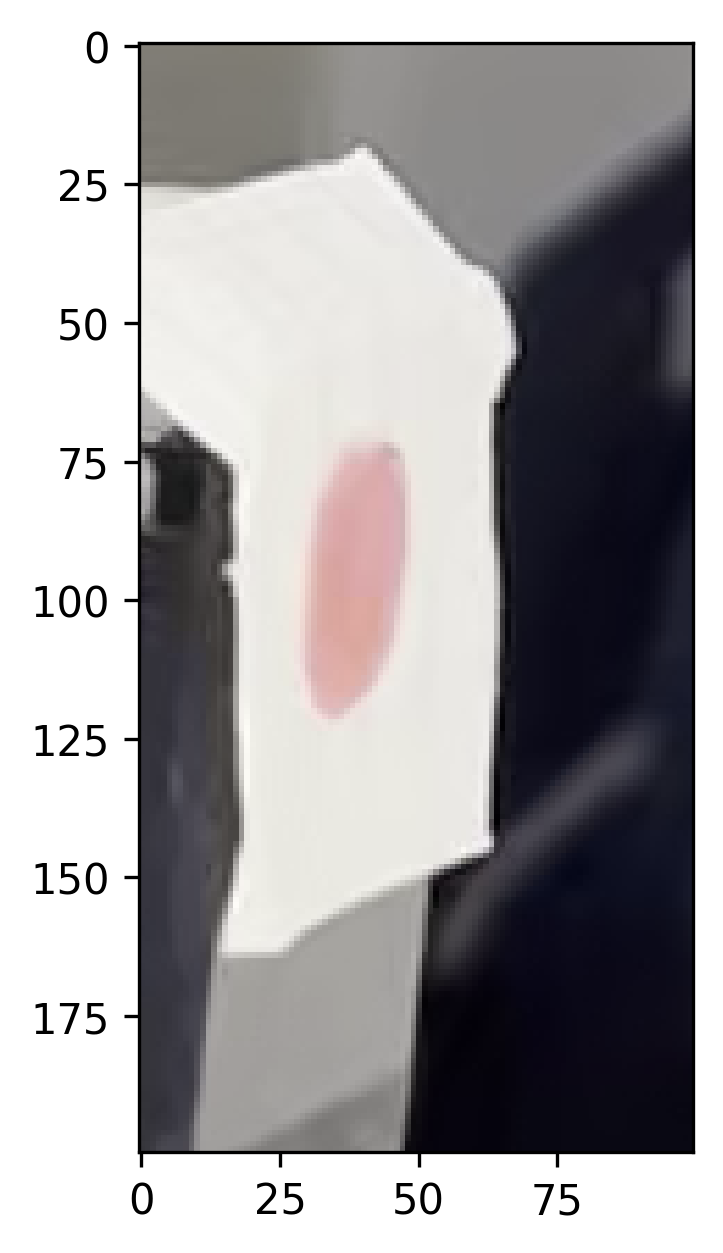

g  [199 236 129]
r  [218 165 157]


In [36]:
import matplotlib.pyplot as plt
import cv2
img_path = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes\0\000001.png"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB
plt.imshow(img)
plt.show()


target_img_g = img[1200:1300,500:550]
target_img_r = img[900:1100,500:600]
plt.figure(dpi=300)
plt.imshow(target_img_g)
plt.show()
plt.figure(dpi=300)
plt.imshow(target_img_r)
plt.show()
print('g ',target_img_g[60,20])
print('r ',target_img_r[100,37])


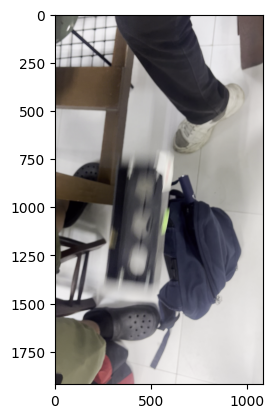

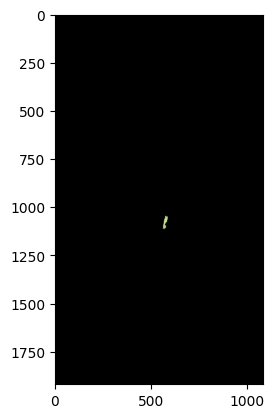

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes\0\000019.png"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Target color (RGB)
target = np.array([199, 236, 129])
tolerance = 20

# Define lower and upper bounds (clipped to [0,255])
lower = np.clip(target - tolerance, 0, 255)
upper = np.clip(target + tolerance, 0, 255)

# Create mask for pixels within this range
mask = cv2.inRange(img, lower, upper)
# Apply mask to image
result = cv2.bitwise_and(img, img, mask=mask)
plt.imshow(img)
plt.show()
plt.imshow(result)
plt.show()

Center of mass: (x=571, y=1080)


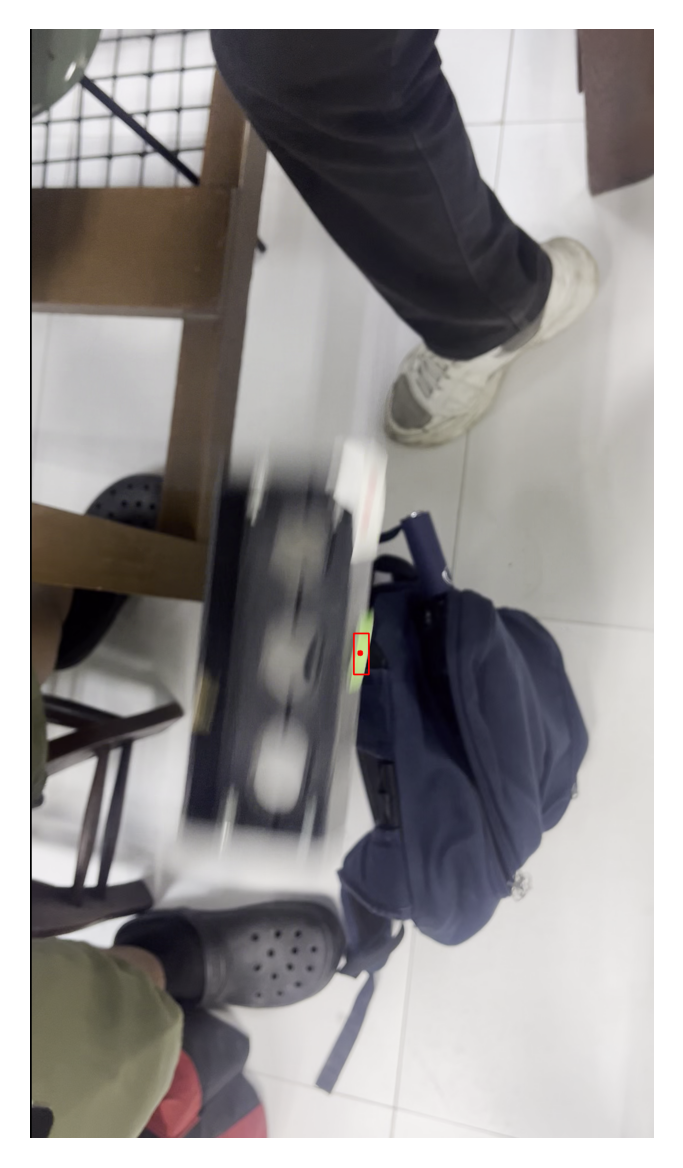

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes\0\000019.png"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Target color (RGB)
target = np.array([199, 236, 129])
tolerance = 20

# Define lower and upper bounds (clipped to [0,255])
lower = np.clip(target - tolerance, 0, 255)
upper = np.clip(target + tolerance, 0, 255)

# Create mask for pixels within this range
mask = cv2.inRange(img, lower, upper)

# Find contours of the masked areas
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy of image for marking
img_marked = img.copy()

if contours:
    # Choose the largest blob
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Draw rectangle around it
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.rectangle(img_marked, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Compute center of mass using image moments
    M = cv2.moments(largest_contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        # Draw a red dot on the centroid
        cv2.circle(img_marked, (cx, cy), 5, (255, 0, 0), -1)
        print(f"Center of mass: (x={cx}, y={cy})")
    else:
        print("Blob area too small — cannot compute centroid.")
else:
    print("No matching regions found.")

# Show result
plt.figure(dpi=300)
plt.imshow(img_marked)
plt.axis("off")
plt.show()


In [ ]:
import os
import cv2
import numpy as np
import csv

# --- Paths ---
source_dir = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes"
frames_dir = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes\0"
positions_dir = os.path.join(os.path.dirname(source_dir), "positions")
# os.makedirs(positions_dir, exist_ok=True)

csv_path = os.path.join(positions_dir, "0.csv")

# --- Target color ---
target = np.array([199, 236, 129])
tolerance = 20
lower = np.clip(target - tolerance, 0, 255)
upper = np.clip(target + tolerance, 0, 255)

# --- Prepare CSV ---
with open(csv_path, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["frame", "x", "y"])

    # --- Process all PNG files sorted by name ---
    for filename in sorted(os.listdir(frames_dir)):
        if filename.lower().endswith(".png"):
            frame_path = os.path.join(frames_dir, filename)
            img = cv2.imread(frame_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Mask based on target RGB
            mask = cv2.inRange(img, lower, upper)

            # Find contours
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                # Pick largest blob
                largest_contour = max(contours, key=cv2.contourArea)
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                else:
                    cx, cy = np.nan, np.nan
            else:
                cx, cy = np.nan, np.nan

            # Write to CSV
            writer.writerow([filename.split(".")[0], cx, cy])
            print(f"{filename} -> x={cx}, y={cy}", end ='\r')

print(f"All positions saved to {csv_path}")


All positions saved to C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\0.csv


In [47]:
import os
import cv2
import numpy as np
import csv

# --- Paths ---
source_dir = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes"
positions_dir = os.path.join(os.path.dirname(source_dir), "positions")

# Target colors and tolerance
target_g500 = (116,164,57)
target = np.array([199, 236, 129])
target_r = np.array([218, 165, 157])
tolerance = 20

# --- Loop over all subdirectories in vidframes ---
for subfolder in sorted(os.listdir(source_dir)):
    frames_dir = os.path.join(source_dir, subfolder)
    if not os.path.isdir(frames_dir):
        continue  # skip files, only process folders

    # Decide which target to use
    if subfolder in ["1000"]:
        lower = np.clip(target_r - tolerance, 0, 255)
        upper = np.clip(target_r + tolerance, 0, 255)
    if subfolder in ['502']:
        lower = np.clip(target_g500 - tolerance, 0, 255)
        upper = np.clip(target_g500 + tolerance, 0, 255)
    else:
        lower = np.clip(target - tolerance, 0, 255)
        upper = np.clip(target + tolerance, 0, 255)

    # CSV path for this folder
    csv_path = os.path.join(positions_dir, f"{subfolder}.csv")

    with open(csv_path, mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["frame", "x", "y"])

        # --- Process all PNG files sorted by name ---
        frame_counter = 0
        for filename in sorted(os.listdir(frames_dir)):
            if frame_counter >= 901:  # stop after 901 frames
                break

            if filename.lower().endswith(".png"):
                frame_path = os.path.join(frames_dir, filename)
                img = cv2.imread(frame_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Mask based on selected target
                mask = cv2.inRange(img, lower, upper)

                # Find contours
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if contours:
                    largest_contour = max(contours, key=cv2.contourArea)
                    M = cv2.moments(largest_contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                    else:
                        cx, cy = np.nan, np.nan
                else:
                    cx, cy = np.nan, np.nan

                # Write to CSV
                writer.writerow([filename.split(".")[0], cx, cy])
                print(f"{subfolder}/{filename} -> x={cx}, y={cy}", end='\r')
                frame_counter += 1

    print(f"\nAll positions saved for folder '{subfolder}' -> {csv_path}")

print('All done.')


0/000901.png -> x=582, y=9933
All positions saved for folder '0' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\0.csv
1000/000901.png -> x=603, y=7183
All positions saved for folder '1000' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\1000.csv
201/000901.png -> x=580, y=9730
All positions saved for folder '201' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\201.csv
289/000901.png -> x=596, y=1015
All positions saved for folder '289' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\289.csv
403/000901.png -> x=581, y=9940
All positions saved for folder '403' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\403.csv
502/000901.png -> x=nan, y=nan6
All positions saved for folder '502' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\502.csv
530/000901.png -> x=592, y=9831
All positions saved for folde

KeyboardInterrupt: 

In [49]:
import os
import cv2
import numpy as np
import csv

# --- Paths ---
source_dir = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\vidframes"
positions_dir = os.path.join(os.path.dirname(source_dir), "positions")

# Target colors and tolerance
target_g500 = np.array([116,164,57])
target = np.array([199, 236, 129])
target_r = np.array([218, 165, 157])
tolerance = 30

# --- Loop over all subdirectories in vidframes ---
for subfolder in sorted(os.listdir(source_dir)):
    frames_dir = os.path.join(source_dir, subfolder)
    if not os.path.isdir(frames_dir):
        continue  # skip files, only process folders

    # Decide which target to use
    if subfolder in ["1000"]:
        lower = np.clip(target_r - tolerance, 0, 255)
        upper = np.clip(target_r + tolerance, 0, 255)
    if subfolder in ['502','Unknown']:
        lower = np.clip(target_g500 - tolerance, 0, 255)
        upper = np.clip(target_g500 + tolerance, 0, 255)
    else:
        lower = np.clip(target - tolerance, 0, 255)
        upper = np.clip(target + tolerance, 0, 255)

    if subfolder != 'Unknown':
        continue

    # CSV path for this folder
    csv_path = os.path.join(positions_dir, f"{subfolder}.csv")

    with open(csv_path, mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["frame", "x", "y"])

        # --- Process all PNG files sorted by name ---
        frame_counter = 0
        for filename in sorted(os.listdir(frames_dir)):
            if frame_counter >= 901:  # stop after 901 frames
                break

            if filename.lower().endswith(".png"):
                frame_path = os.path.join(frames_dir, filename)
                img = cv2.imread(frame_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Mask based on selected target
                mask = cv2.inRange(img, lower, upper)

                # Find contours
                contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if contours:
                    largest_contour = max(contours, key=cv2.contourArea)
                    M = cv2.moments(largest_contour)
                    if M["m00"] != 0:
                        cx = int(M["m10"] / M["m00"])
                        cy = int(M["m01"] / M["m00"])
                    else:
                        cx, cy = np.nan, np.nan
                else:
                    cx, cy = np.nan, np.nan

                # Write to CSV
                writer.writerow([filename.split(".")[0], cx, cy])
                print(f"{subfolder}/{filename} -> x={cx}, y={cy}", end='\r')
                frame_counter += 1

    print(f"\nAll positions saved for folder '{subfolder}' -> {csv_path}")

print('All done.')


Unknown/000900.png -> x=570, y=1003
All positions saved for folder 'Unknown' -> C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\Unknown.csv
All done.
